# Um projeto de baixa dimensionalidade e o baseline

In [1]:
import pandas as pd

uri = 'https://gist.githubusercontent.com/guilhermesilveira/12291c548acaf544596795709020e3db/raw/325bdef098bd9cbc2189215b7e32e22f437f29f3/projetos.csv'

dados = pd.read_csv(uri)
dados.head()

,nao_finalizado,horas_esperadas,preco
0,0,75.0,6985.000000
1,1,0.0,4325.293458
2,0,87.0,14205.000000
3,1,13.0,100.000000
4,0,2.0,202.000000


In [2]:
# manipulando os dados
dados["finalizado"] = dados.nao_finalizado.map({0:1, 1:0})
dados.head()

,nao_finalizado,horas_esperadas,preco,finalizado
0,0,75.0,6985.000000,1
1,1,0.0,4325.293458,0
2,0,87.0,14205.000000,1
3,1,13.0,100.000000,0
4,0,2.0,202.000000,1


<Axes: xlabel='horas_esperadas', ylabel='preco'>

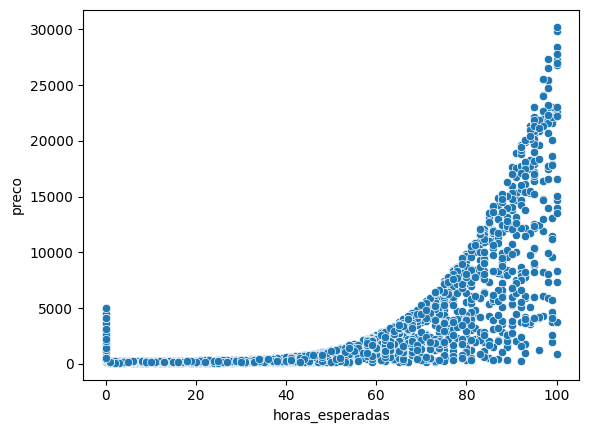

In [3]:
import seaborn as sns

sns.scatterplot(x='horas_esperadas', y='preco', data=dados)

<Axes: xlabel='horas_esperadas', ylabel='preco'>

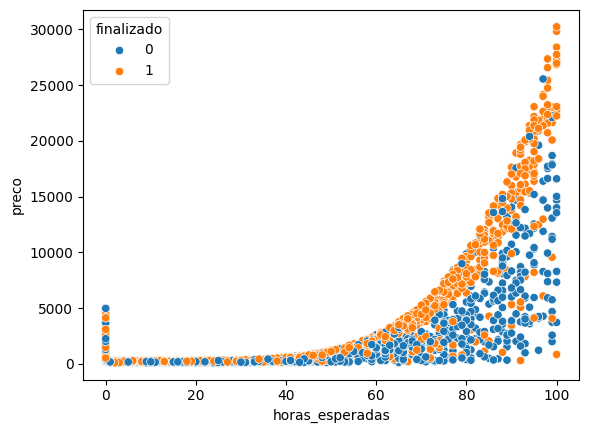

In [4]:
sns.scatterplot(x='horas_esperadas', y='preco', data=dados, hue='finalizado')

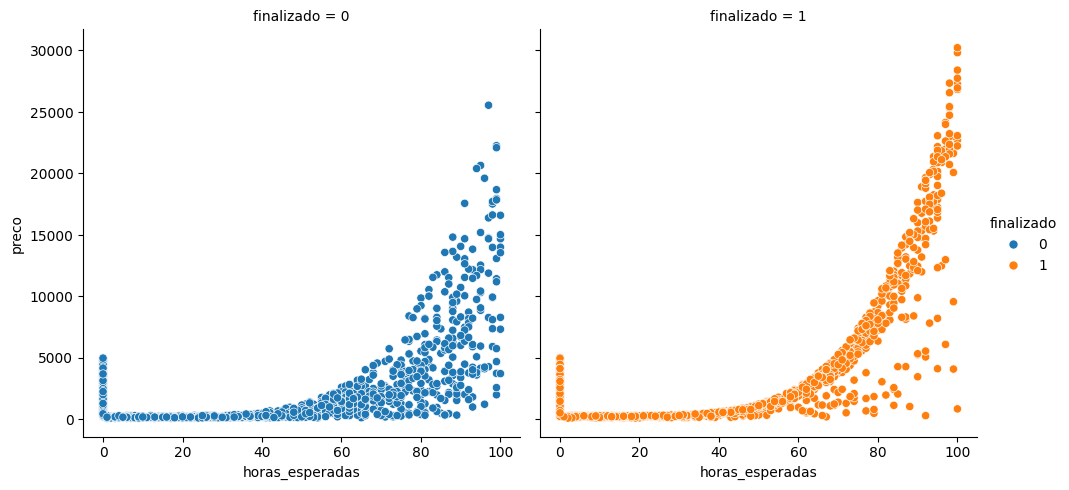

In [5]:
sns.relplot(x='horas_esperadas', y='preco', data=dados, hue='finalizado', col='finalizado')

In [6]:
# limpeza de dados
dados = dados.query('horas_esperadas > 0')

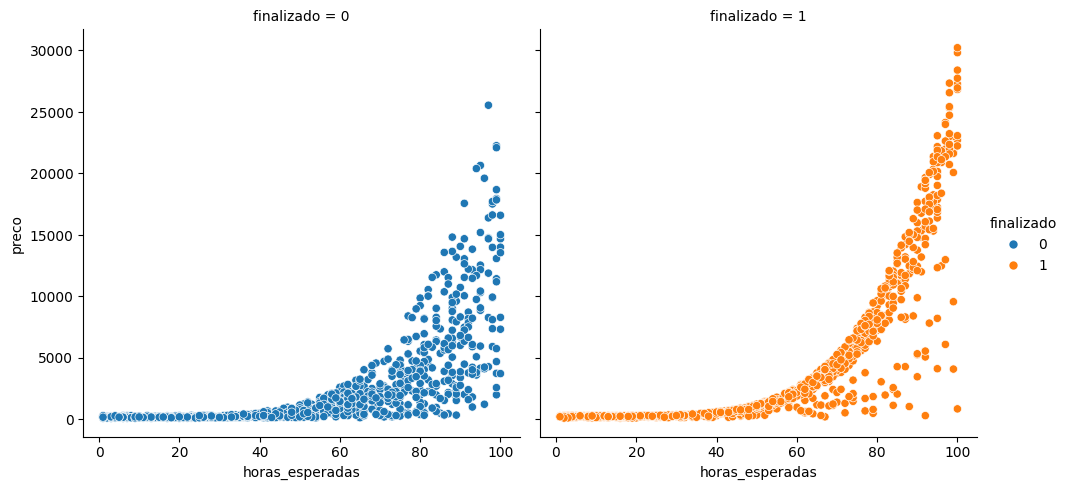

In [7]:
sns.relplot(x='horas_esperadas', y='preco', data=dados, hue='finalizado', col='finalizado')

In [8]:
x = dados[['horas_esperadas', 'preco']]
y = dados['finalizado']

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

seed = 23

treino_x, teste_x, treino_y, teste_y = train_test_split(x, y, random_state=seed,
                                                        test_size=0.25, stratify=y)

print(f'Tamanho do treino: {len(treino_x)}')
print(f'Tamanho do teste: {len(teste_x)}')

modelo = LinearSVC()
modelo.fit(treino_x, treino_y)
previsoes = modelo.predict(teste_x)

acuracia = accuracy_score(teste_y, previsoes) * 100
print(f'A acurácia foi de {acuracia:.2f}%')

Tamanho do treino: 1617
Tamanho do teste: 540
A acurácia foi de 58.15%


In [10]:
previsoes_de_base = teste_y.value_counts(normalize=True) * 100
# chuta que todos vão finalizar o projeto, por exemplo
print(f'A acurácia do modelo de base foi de {previsoes_de_base[1]:.2f}%')

A acurácia do modelo de base foi de 52.59%


In [11]:
x_min = teste_x['horas_esperadas'].min()
x_max = teste_x['horas_esperadas'].max()
y_min = teste_x['preco'].min()
y_max = teste_x['preco'].max()

print(f'X min: {x_min}, X max: {x_max}')
print(f'Y min: {y_min}, Y max: {y_max}')

X min: 1.0, X max: 100.0
Y min: 100.0, Y max: 27343.0


In [12]:
import numpy as np

pixels = 100

eixo_x = np.arange(x_min, x_max, (x_max - x_min)/pixels)
eixo_y = np.arange(y_min, y_max, (y_max - y_min)/pixels)


In [13]:
xx, yy = np.meshgrid(eixo_x, eixo_y)
xx.ravel() # junta todos os elementos do array em uma única dimensão

pontos = np.c_[xx.ravel(), yy.ravel()] # cria um array com duas colunas, uma para cada eixo

In [14]:
Z = modelo.predict(pontos)
Z = Z.reshape(xx.shape)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearSVC was fitted with feature names
  warnings.warn(


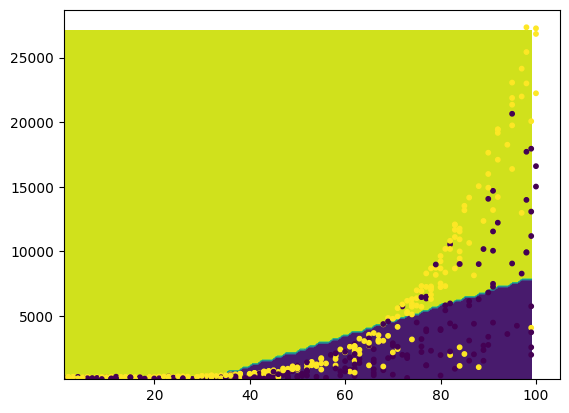

In [15]:
import matplotlib.pyplot as plt

plt.contourf(xx, yy, Z)
plt.scatter(teste_x['horas_esperadas'], teste_x['preco'], c=teste_y, s=10)

# Aula 4: Support Vector Machine e a não linearidade

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

seed = 23

treino_x, teste_x, treino_y, teste_y = train_test_split(x, y, random_state=seed,
                                                        test_size=0.25, stratify=y)

print(f'Tamanho do treino: {len(treino_x)}')
print(f'Tamanho do teste: {len(teste_x)}')

modelo2 = SVC(gamma='auto')
modelo2.fit(treino_x, treino_y)
previsoes = modelo2.predict(teste_x)

acuracia = accuracy_score(teste_y, previsoes) * 100
print(f'A acurácia foi de {acuracia:.2f}%')

Tamanho do treino: 1617
Tamanho do teste: 540
A acurácia foi de 60.37%


X min: 1.0, X max: 100.0
Y min: 100.0, Y max: 27343.0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


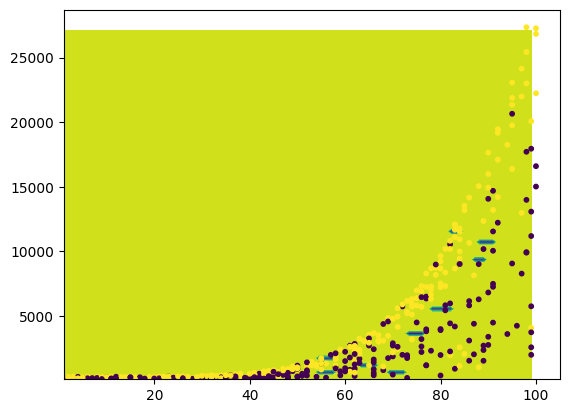

In [22]:
x_min = teste_x['horas_esperadas'].min()
x_max = teste_x['horas_esperadas'].max()
y_min = teste_x['preco'].min()
y_max = teste_x['preco'].max()

print(f'X min: {x_min}, X max: {x_max}')
print(f'Y min: {y_min}, Y max: {y_max}')

pixels = 100

eixo_x = np.arange(x_min, x_max, (x_max - x_min)/pixels)
eixo_y = np.arange(y_min, y_max, (y_max - y_min)/pixels)

xx, yy = np.meshgrid(eixo_x, eixo_y)
xx.ravel() # junta todos os elementos do array em uma única dimensão

pontos = np.c_[xx.ravel(), yy.ravel()]

Z = modelo2.predict(pontos)
Z = Z.reshape(xx.shape)


plt.contourf(xx, yy, Z)
plt.scatter(teste_x['horas_esperadas'], teste_x['preco'], c=teste_y, s=10)

In [23]:
from sklearn.preprocessing import StandardScaler

seed = 23

raw_treino_x, raw_teste_x, treino_y, teste_y = train_test_split(x, y, random_state=seed,
                                                        test_size=0.25, stratify=y)

print(f'Tamanho do treino: {len(raw_treino_x)}')
print(f'Tamanho do teste: {len(raw_teste_x)}')

scaler = StandardScaler()
scaler.fit(raw_treino_x)

treino_x = scaler.transform(raw_treino_x)
teste_x = scaler.transform(raw_teste_x)

modelo2 = SVC(gamma='auto')
modelo2.fit(treino_x, treino_y)
previsoes = modelo2.predict(teste_x)

acuracia = accuracy_score(teste_y, previsoes) * 100
print(f'A acurácia foi de {acuracia:.2f}%')

Tamanho do treino: 1617
Tamanho do teste: 540
A acurácia foi de 67.41%


X min: -1.7449496436878291, X max: 1.7347117015353204
Y min: -0.5981734634977938, Y max: 4.807227269204064


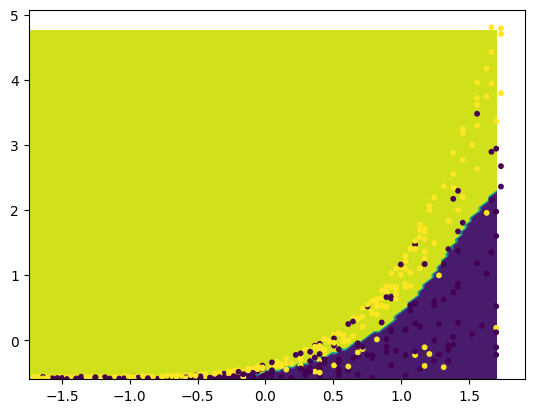

In [24]:
data_col1 = teste_x[:, 0]
data_col2 = teste_x[:, 1]

x_min = data_col1.min()
x_max = data_col1.max()
y_min = data_col2.min()
y_max = data_col2.max()

print(f'X min: {x_min}, X max: {x_max}')
print(f'Y min: {y_min}, Y max: {y_max}')

pixels = 100

eixo_x = np.arange(x_min, x_max, (x_max - x_min)/pixels)
eixo_y = np.arange(y_min, y_max, (y_max - y_min)/pixels)

xx, yy = np.meshgrid(eixo_x, eixo_y)
xx.ravel() # junta todos os elementos do array em uma única dimensão

pontos = np.c_[xx.ravel(), yy.ravel()]

Z = modelo2.predict(pontos)
Z = Z.reshape(xx.shape)


plt.contourf(xx, yy, Z)
plt.scatter(data_col1, data_col2, c=teste_y, s=10)